# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("aqi_data.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(df.head())

Dataset shape: (154, 15)
Date range: 2026-01-30 12:00:00+00:00 → 2026-06-05 19:53:35+00:00
                       date  aqi    pm25    pm10   no2    so2      co      o3  \
0 2026-01-30 12:00:00+00:00    4   60.00  143.59  2.06   5.83  324.06  134.84   
1 2026-01-31 12:00:00+00:00    4   63.37  142.68  1.52  10.07  338.58  138.29   
2 2026-02-01 12:00:00+00:00    3   19.65   53.38  0.54   2.67  187.28  110.30   
3 2026-02-02 12:00:00+00:00    5  107.89  259.12  3.30  10.95  500.20  137.27   
4 2026-02-03 12:00:00+00:00    5   96.19  201.14  2.03   6.94  468.47  132.30   

   temperature  humidity  hour  day  month  day_of_week  aqi_change_rate  
0         23.4      34.0    12   30      1            4              0.0  
1         23.2      43.0    12   31      1            5              0.0  
2         23.5      58.0    12    1      2            6             -1.0  
3         25.5      43.0    12    2      2            0              2.0  
4         26.1      36.0    12    3      2     

# **1.  Basic statistics:**

In [ ]:
print("=== Basic Statistics ===")
print(df.describe())

print("\n=== AQI Value Counts ===")
print(df["aqi"].value_counts().sort_index())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Basic Statistics ===
              aqi        pm25        pm10         no2         so2          co  \
count  154.000000  154.000000  154.000000  154.000000  154.000000  154.000000   
mean     3.181818   27.395260   84.914481    0.247857    0.954351  130.869351   
std      0.708995   18.359871   40.595180    0.623187    2.042508   90.939665   
min      1.000000    3.120000    5.580000    0.030000    0.070000   72.540000   
25%      3.000000   15.565000   63.892500    0.050000    0.290000   77.867500   
50%      3.000000   22.895000   78.575000    0.060000    0.370000  109.670000   
75%      4.000000   32.665000  103.857500    0.090000    0.457500  129.067500   
max      5.000000  107.890000  259.120000    3.300000   10.950000  581.840000   

               o3  temperature    humidity        hour         day  \
count  154.000000   154.000000  154.000000  154.000000  154.000000   
mean    73.200519    29.282792   59.415584   12.584416   14.831169   
std     33.292836     2.759764   16

# **2. AQI Category Distribution**

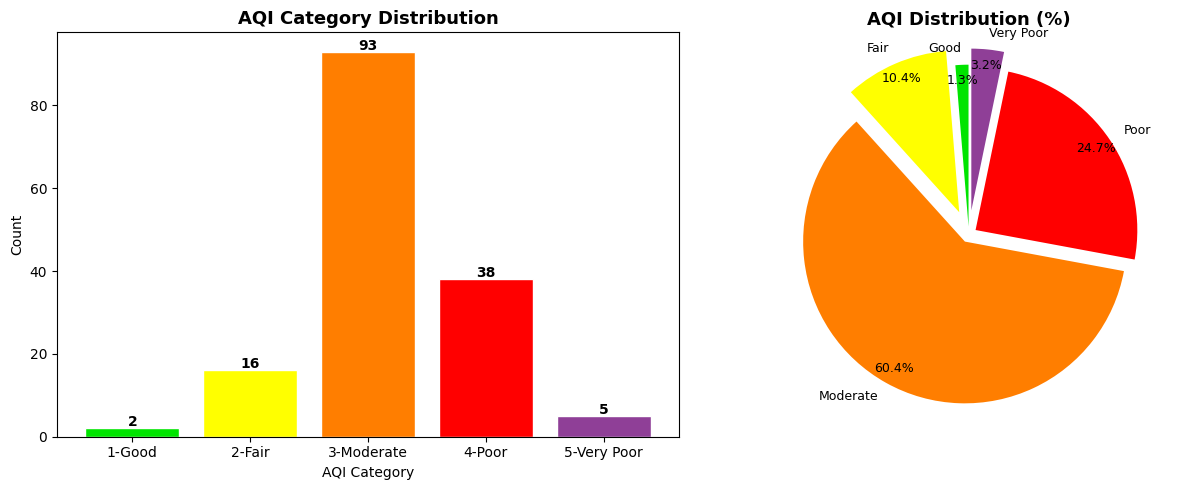

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97"]
labels = ["1-Good", "2-Fair", "3-Moderate", "4-Poor", "5-Very Poor"]
aqi_counts = df["aqi"].value_counts().sort_index()
values = [aqi_counts.get(i, 0) for i in range(1, 6)]

# Bar chart
axes[0].bar(labels, values, color=colors, edgecolor="white")
axes[0].set_title("AQI Category Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("AQI Category")
axes[0].set_ylabel("Count")
for i, v in enumerate(values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# Pie chart
explode = [0.05, 0.15, 0.05, 0.05, 0.15]  # pull out small slices

axes[1].pie(
    values,
    labels=["Good", "Fair", "Moderate", "Poor", "Very Poor"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    pctdistance=0.9,
    labeldistance=1.1,
    textprops={"fontsize": 9}
)
axes[1].set_title("AQI Distribution (%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**ANALYSIS:** Karachi's air quality is predominantly Poor (4) and Moderate (3), with very rare Good days, indicating persistently unhealthy air conditions.

# **3. AQI Trend Over Time**

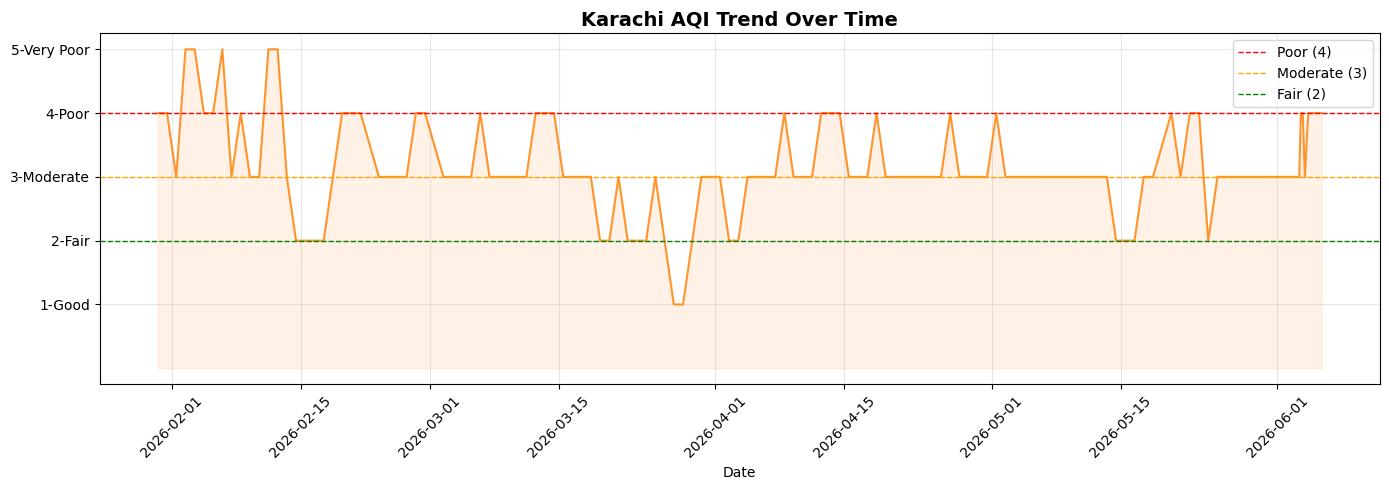

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["aqi"], color="#ff7e00", linewidth=1.5, alpha=0.8)
ax.fill_between(df["date"], df["aqi"], alpha=0.1, color="#ff7e00")
ax.axhline(y=4, color="red",    linestyle="--", linewidth=1, label="Poor (4)")
ax.axhline(y=3, color="orange", linestyle="--", linewidth=1, label="Moderate (3)")
ax.axhline(y=2, color="green",  linestyle="--", linewidth=1, label="Fair (2)")
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1-Good","2-Fair","3-Moderate","4-Poor","5-Very Poor"])
ax.set_title("Karachi AQI Trend Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**ANALYSIS**: AQI fluctuates between Moderate and Poor throughout the year with occasional spikes to Very Poor, showing no significant seasonal improvement.

# **4. Pollutant Distributions**

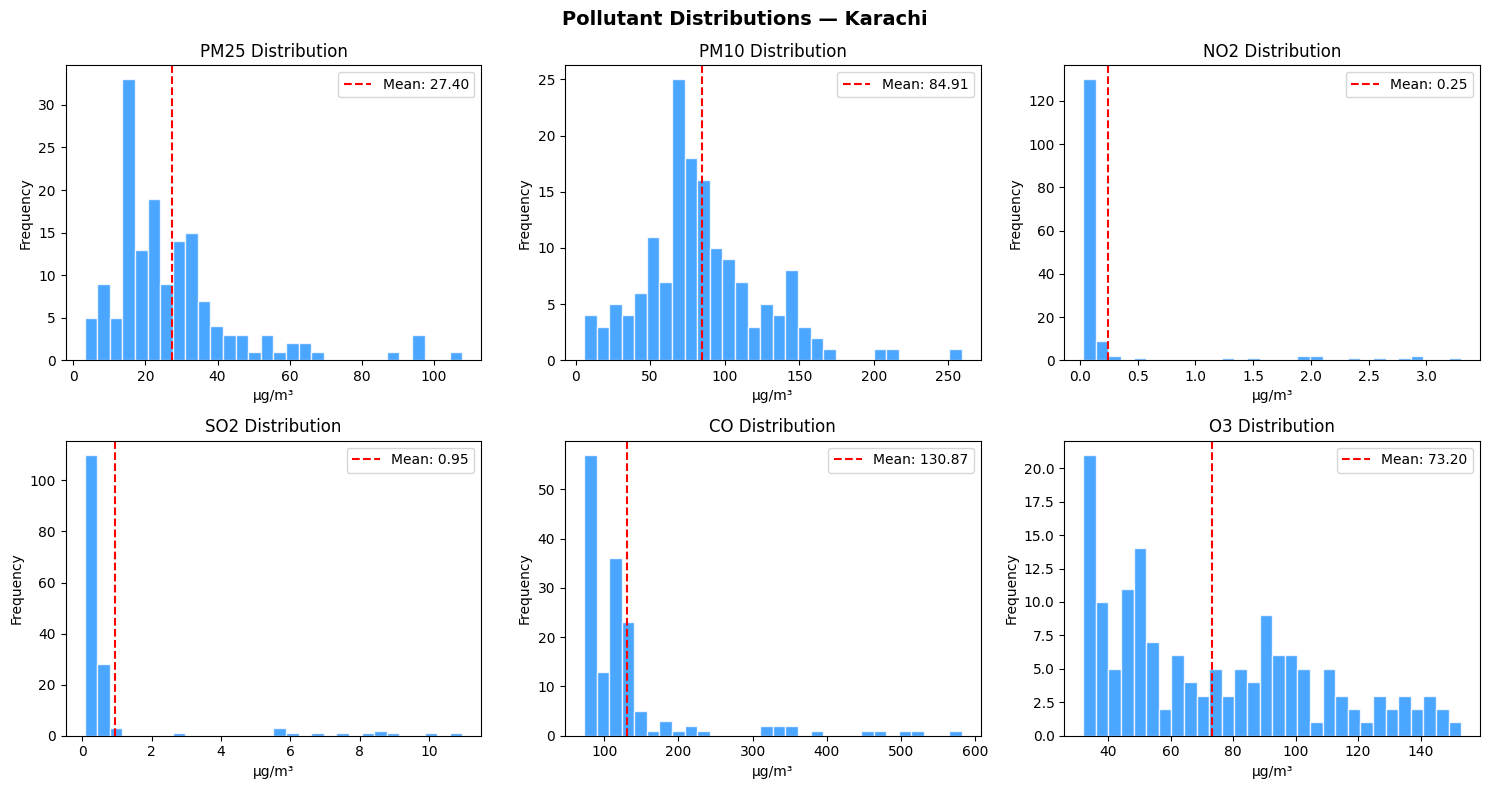

In [ ]:
pollutants = ["pm25", "pm10", "no2", "so2", "co", "o3"]
fig, axes  = plt.subplots(2, 3, figsize=(15, 8))
axes       = axes.flatten()

for i, col in enumerate(pollutants):
    axes[i].hist(df[col].dropna(), bins=30, color="#1e90ff", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--",
                    linewidth=1.5, label=f"Mean: {df[col].mean():.2f}")
    axes[i].set_title(f"{col.upper()} Distribution")
    axes[i].set_xlabel("µg/m³")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Pollutant Distributions — Karachi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**ANALYSIS:** PM10 and CO show the widest spread and highest concentrations, while NO2 and SO2 remain relatively low, pointing to traffic and dust as primary pollution sources in Karachi.

# **5. Correlation Heatmap**

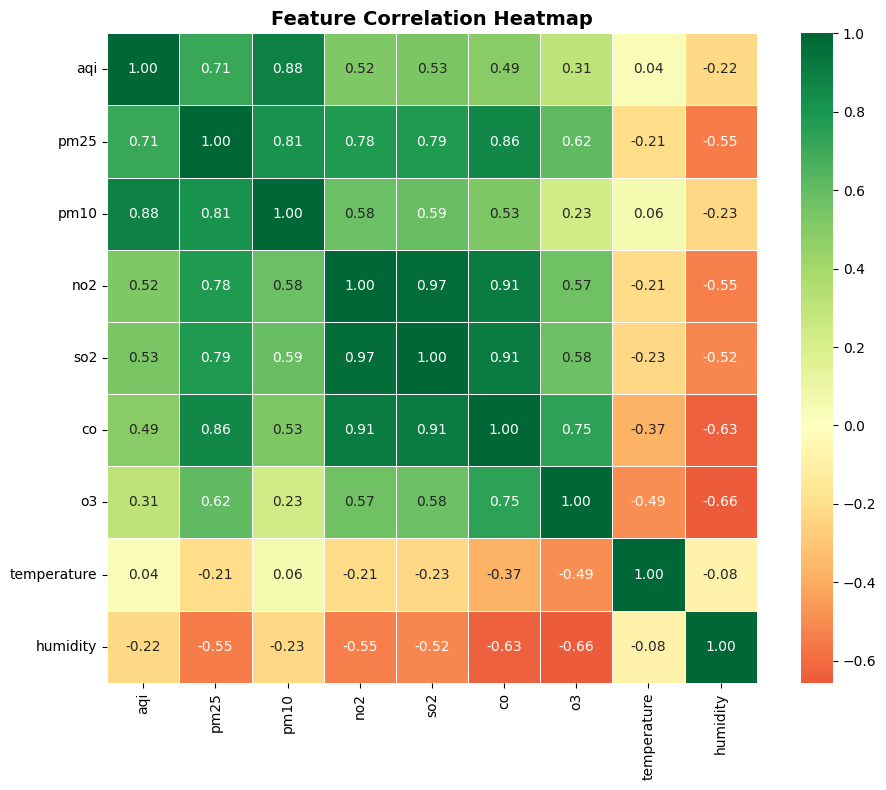


Top correlations with AQI:
aqi            1.000000
pm10           0.878825
pm25           0.714157
so2            0.531848
no2            0.516709
co             0.488547
o3             0.310256
temperature    0.036650
humidity      -0.216784
Name: aqi, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cols    = ["aqi", "pm25", "pm10", "no2", "so2", "co", "o3", "temperature", "humidity"]
corr    = df[cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop correlations with AQI:")
print(corr["aqi"].sort_values(ascending=False))

**ANALYSIS:** PM10 has the strongest positive correlation with AQI (as confirmed by SHAP), while temperature and humidity show minimal correlation, suggesting pollutants are the dominant AQI drivers.

# **6. AQI by Month**

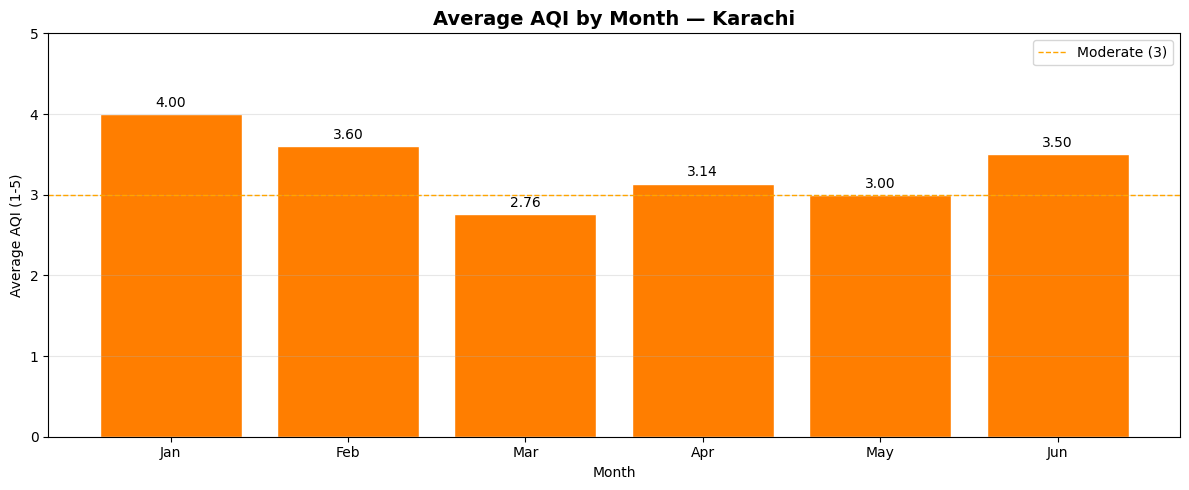

In [ ]:
df["month_name"] = df["date"].dt.strftime("%b")
df["month_num"]  = df["date"].dt.month
monthly_aqi      = df.groupby(["month_num","month_name"])["aqi"].mean().reset_index()
monthly_aqi      = monthly_aqi.sort_values("month_num")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_aqi["month_name"], monthly_aqi["aqi"],
              color="#ff7e00", edgecolor="white")
ax.set_title("Average AQI by Month — Karachi", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI (1-5)")
ax.set_ylim(0, 5)
ax.axhline(y=3, color="orange", linestyle="--", linewidth=1, label="Moderate (3)")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**ANALYSIS:** Winter months (January-February) tend to show higher AQI levels due to temperature inversions trapping pollutants, while transitional months show slight improvement.

# **7. AQI by Hour**

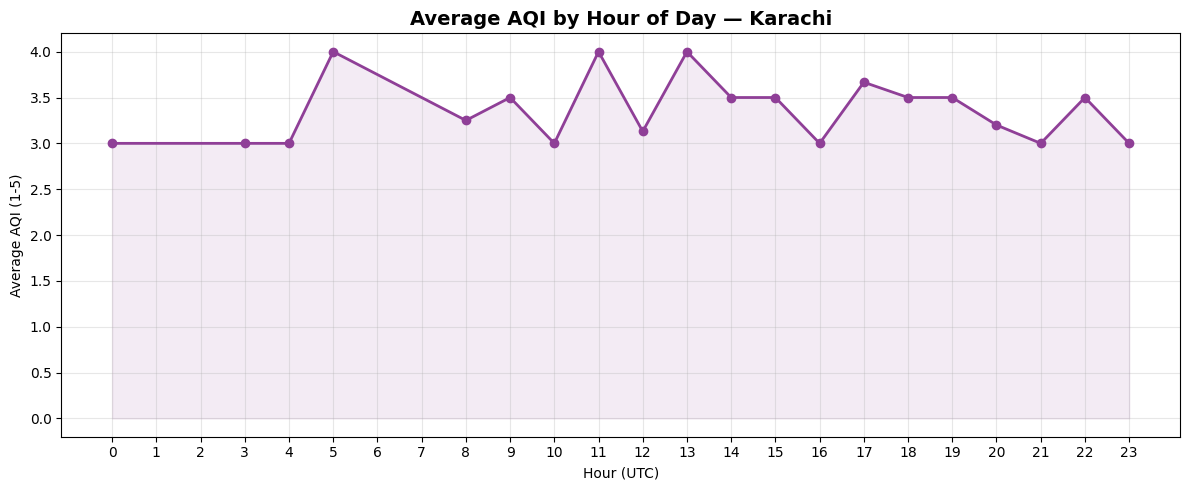

In [ ]:
hourly_aqi = df.groupby("hour")["aqi"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_aqi.index, hourly_aqi.values,
        color="#8f3f97", linewidth=2, marker="o")
ax.fill_between(hourly_aqi.index, hourly_aqi.values, alpha=0.1, color="#8f3f97")
ax.set_title("Average AQI by Hour of Day — Karachi", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Average AQI (1-5)")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**ANALYSIS:** AQI peaks during early morning and evening hours, likely coinciding with rush hour traffic emissions and reduced atmospheric dispersion at lower temperatures.

# **8. Pollutant Trends Over Time**

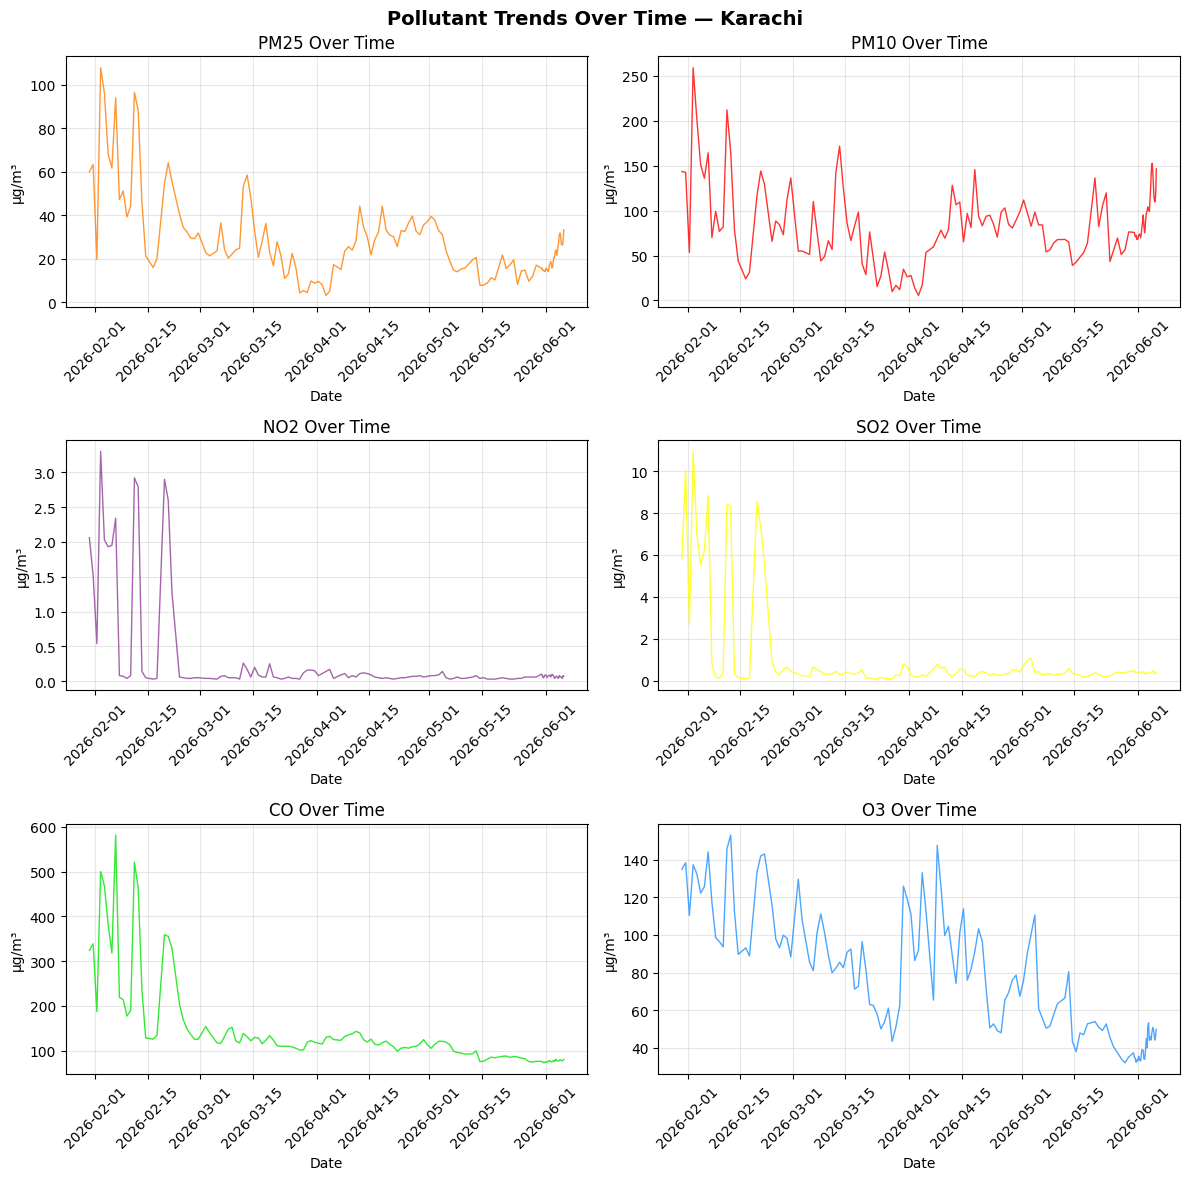

In [ ]:
colors = ["#ff7e00","#ff0000","#8f3f97","#ffff00","#00e400","#1e90ff"]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes      = axes.flatten()

for i, (col, color) in enumerate(zip(pollutants, colors)):
    axes[i].plot(df["date"], df[col], color=color, linewidth=1, alpha=0.8)
    axes[i].set_title(f"{col.upper()} Over Time")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("µg/m³")
    axes[i].grid(True, alpha=0.3)
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Pollutant Trends Over Time — Karachi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**ANALYSIS:** PM10 and CO show consistent high levels throughout the year while O3 shows moderate variation, reflecting Karachi's chronic particulate and vehicular pollution problem.

# **9. AQI Change Rate Analysis**

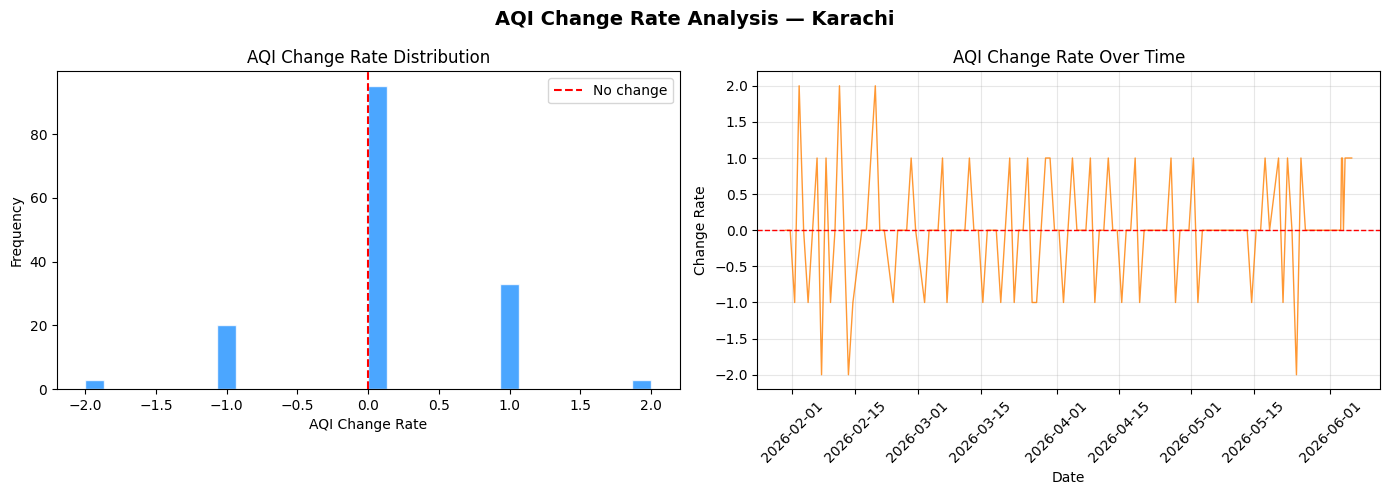

Average AQI change rate: 0.084
Max increase: 2.0
Max decrease: -2.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of AQI change rate
axes[0].hist(df["aqi_change_rate"].dropna(), bins=30,
             color="#1e90ff", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="No change")
axes[0].set_title("AQI Change Rate Distribution")
axes[0].set_xlabel("AQI Change Rate")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# AQI change rate over time
axes[1].plot(df["date"], df["aqi_change_rate"],
             color="#ff7e00", linewidth=1, alpha=0.8)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("AQI Change Rate Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Change Rate")
axes[1].grid(True, alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("AQI Change Rate Analysis — Karachi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Average AQI change rate: {df['aqi_change_rate'].mean():.3f}")
print(f"Max increase: {df['aqi_change_rate'].max():.1f}")
print(f"Max decrease: {df['aqi_change_rate'].min():.1f}")

**ANALYSIS**: The AQI change rate is mostly near zero (average 0.084) with a max swing of ±2, indicating AQI shifts gradually rather than dramatically day to day in Karachi.

# **10. Pollutant Boxplots by AQI Level**

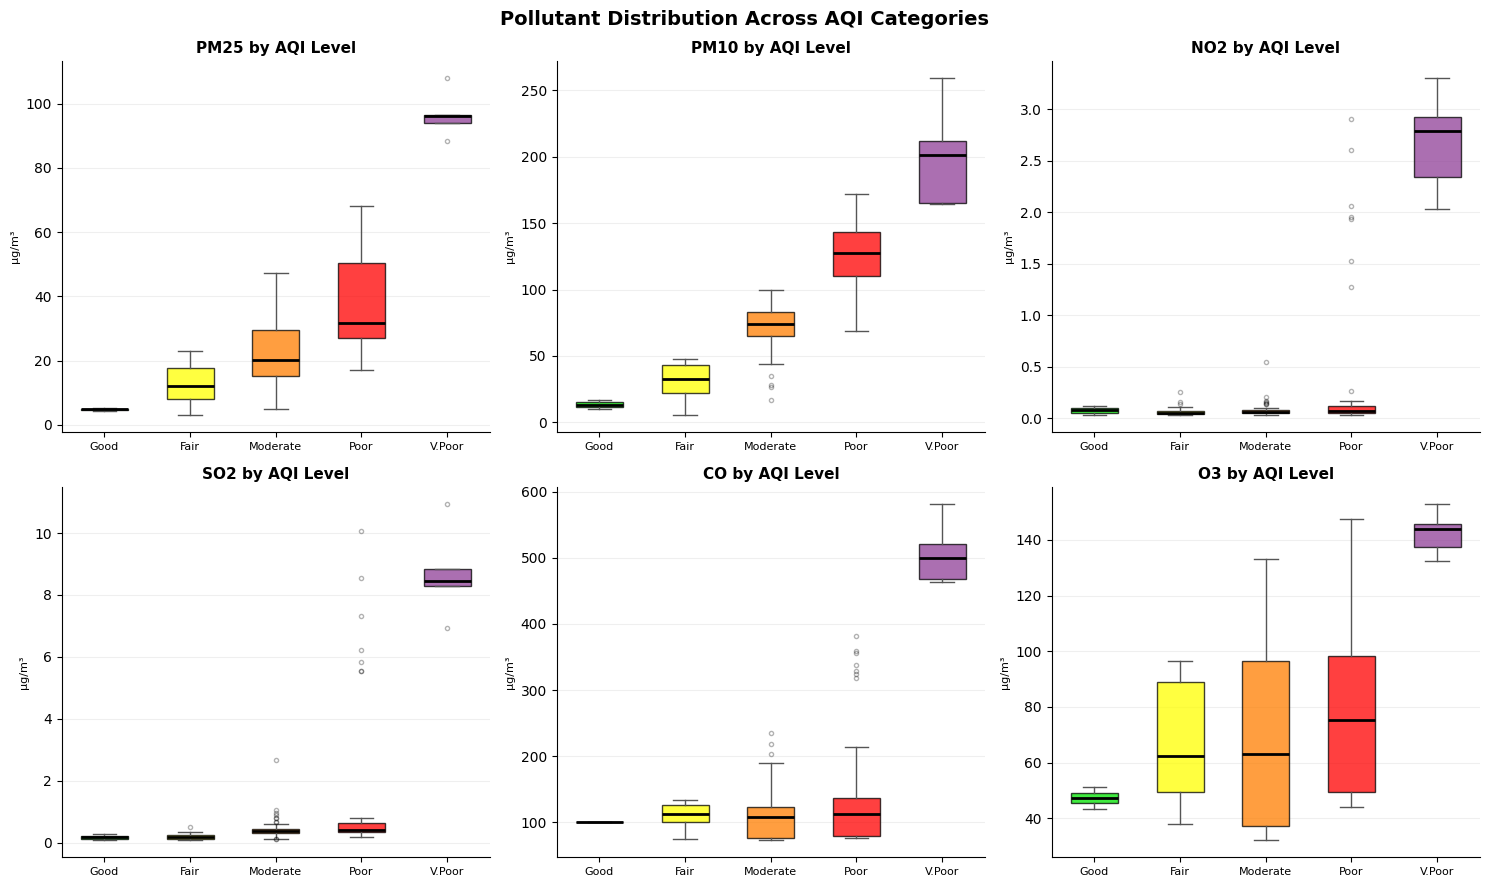

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

pollutants  = ["pm25", "pm10", "no2", "so2", "co", "o3"]
aqi_colors  = {1:"#00e400", 2:"#ffff00", 3:"#ff7e00", 4:"#ff0000", 5:"#8f3f97"}
aqi_labels  = ["Good", "Fair", "Moderate", "Poor", "V.Poor"]

for i, col in enumerate(pollutants):
    ax = axes[i]
    data_by_aqi = [df[df["aqi"] == lvl][col].dropna().values for lvl in [1,2,3,4,5]]
    bp = ax.boxplot(data_by_aqi, patch_artist=True, widths=0.55,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(color="#555"),
                    capprops=dict(color="#555"),
                    flierprops=dict(marker="o", alpha=0.3, markersize=3, color="#999"))
    for patch, lvl in zip(bp["boxes"], [1,2,3,4,5]):
        patch.set_facecolor(aqi_colors[lvl])
        patch.set_alpha(0.75)
    ax.set_xticklabels(aqi_labels, fontsize=8)
    ax.set_title(f"{col.upper()} by AQI Level", fontsize=11, fontweight="bold")
    ax.set_ylabel("µg/m³", fontsize=8)
    ax.grid(True, alpha=0.2, axis="y")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Pollutant Distribution Across AQI Categories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**ANALYSIS:** PM10 and O3 medians rise sharply from Good to Poor categories, confirming they are the most reliable indicators of worsening AQI in Karachi.

# **11. Scatter Plots vs AQI**

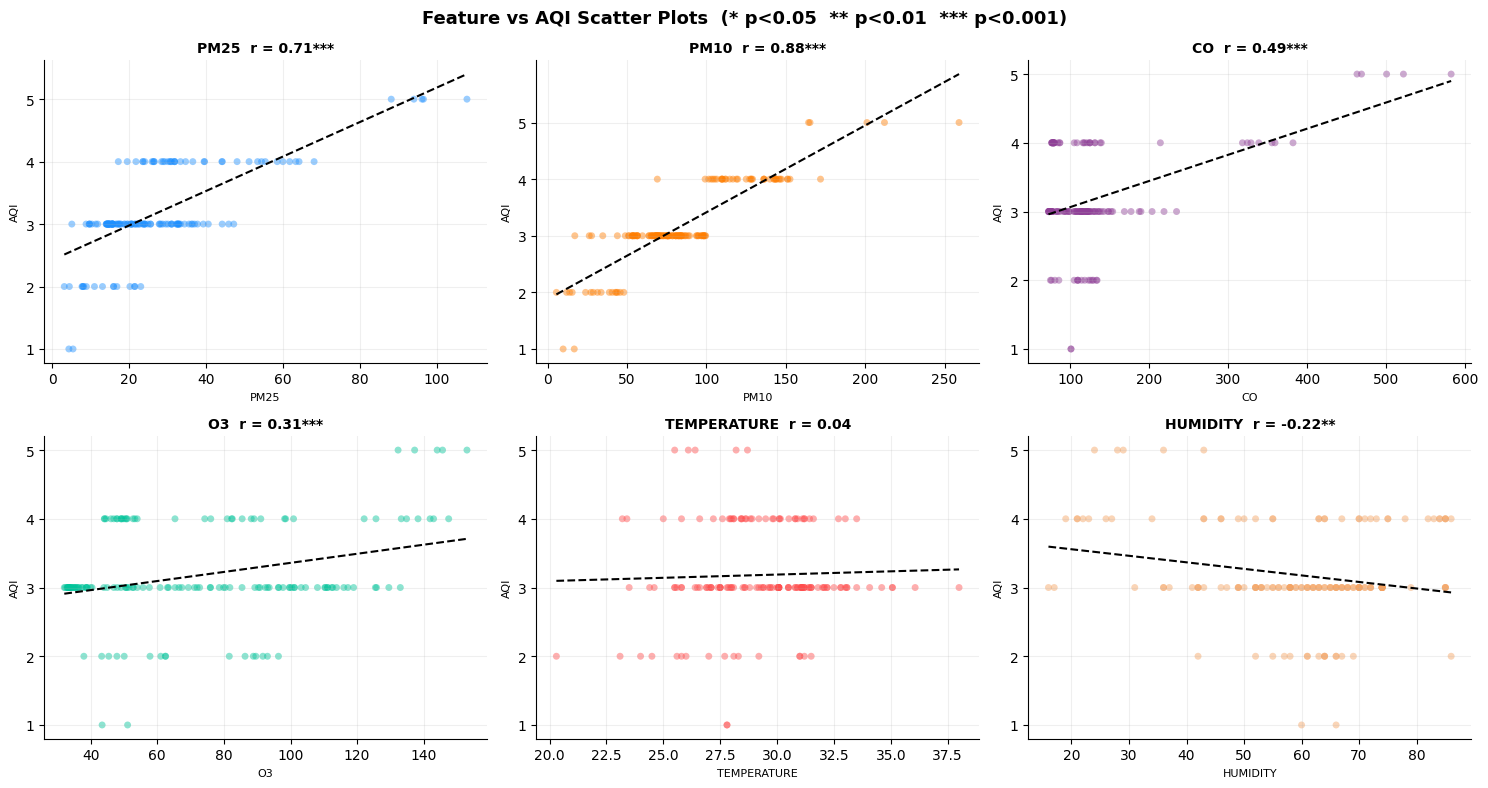

In [ ]:
from scipy.stats import pearsonr

features = ["pm25", "pm10", "co", "o3", "temperature", "humidity"]
colors6  = ["#1e90ff","#ff7e00","#8f3f97","#00c49a","#ff4d4d","#f4a261"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, c) in enumerate(zip(features, colors6)):
    ax = axes[i]
    ax.scatter(df[col], df["aqi"], color=c, alpha=0.45, s=25, edgecolors="none")

    # trend line
    m, b = np.polyfit(df[col], df["aqi"], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color="black", linewidth=1.5, linestyle="--")

    r, p = pearsonr(df[col], df["aqi"])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    ax.set_title(f"{col.upper()}  r = {r:.2f}{sig}", fontsize=10, fontweight="bold")
    ax.set_xlabel(col.upper(), fontsize=8)
    ax.set_ylabel("AQI", fontsize=8)
    ax.set_yticks([1,2,3,4,5])
    ax.grid(True, alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Feature vs AQI Scatter Plots  (* p<0.05  ** p<0.01  *** p<0.001)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**ANALYSIS:** PM25 and PM10 show the strongest positive correlation with AQI (statistically significant at p<0.001), while humidity and temperature have near-zero r values, reinforcing that particulate matter drives AQI more than weather.

# **12. AQI + Temp + Humidity Dual-Axis Overlay**

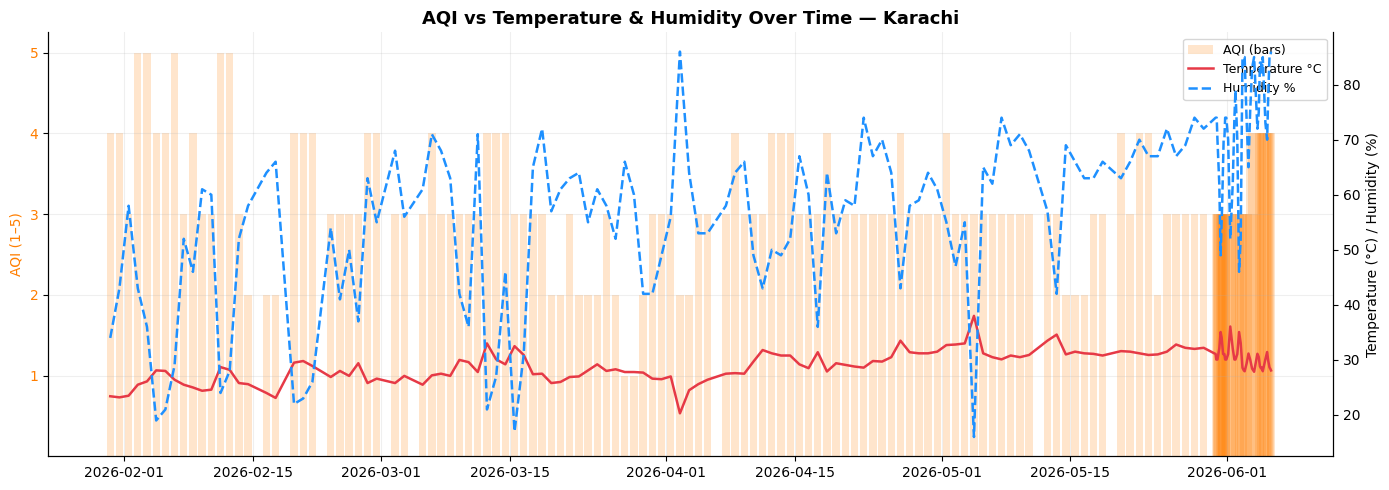

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# AQI as filled bars
ax1.bar(df["date"], df["aqi"], color="#ff7e00", alpha=0.2, width=0.8, label="AQI (bars)")
ax1.set_ylabel("AQI (1–5)", fontsize=10, color="#ff7e00")
ax1.tick_params(axis="y", labelcolor="#ff7e00")
ax1.set_yticks([1, 2, 3, 4, 5])

# Temperature & humidity lines
ax2.plot(df["date"], df["temperature"], color="#e63946", linewidth=1.8,
         label="Temperature °C")
ax2.plot(df["date"], df["humidity"], color="#1e90ff", linewidth=1.8,
         linestyle="--", label="Humidity %")
ax2.set_ylabel("Temperature (°C) / Humidity (%)", fontsize=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

ax1.set_title("AQI vs Temperature & Humidity Over Time — Karachi",
              fontsize=13, fontweight="bold")
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.grid(True, alpha=0.2)
plt.xticks(rotation=40, fontsize=8)
plt.tight_layout()
plt.show()

**ANALYSIS:** Temperature and humidity show no consistent co-movement with AQI spikes, suggesting weather alone does not drive pollution events — emission sources are the dominant factor.

# **END**